# 🧪 TARUR — Nonlinear Unit Root Testing Library
## Complete Tutorial with Real Financial Data

**Author:** Dr. Merwan Roudane  
**Email:** merwanroudane920@gmail.com  
**GitHub:** [github.com/merwanroudane/tarur](https://github.com/merwanroudane/tarur)  
**Version:** 1.0.0

---

### What is TARUR?

**TARUR** is a comprehensive Python library implementing **17+ nonlinear unit root, cointegration, and linearity tests** with:

- ✅ Embedded critical values from original papers
- ✅ Automatic reject/accept decisions at 1%, 5%, 10%
- ✅ Publication-quality tables & visualizations
- ✅ Bug fixes over existing R implementations

### Tests Covered

| Category | Tests |
|----------|-------|
| **ESTAR Unit Root** | KSS (2003), Kruse (2011), Sollis (2009), Hu & Chen (2016) |
| **Smooth Transition** | LNV (1998), Vougas (2006), Harvey & Mills (2002) |
| **Asymmetric/TAR** | Enders & Granger (1998), Sollis (2004), Cook & Vougas (2009) |
| **Grid-Search** | Kılıç (2011), Park & Shintani (2016) |
| **Extended** | Pascalau (2007), Cuestas & Garratt (2011), Cuestas & Ordóñez (2014) |
| **Cointegration** | KSS (2006), Enders & Siklos (2001) |
| **Linearity** | Teräsvirta (1994), ARCH, McLeod-Li |

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
    'figure.facecolor': 'white',
})

import tarur
print(f"TARUR version: {tarur.__version__}")

TARUR version: 1.0.0


## 2. Real Financial Data

We use three empirically relevant time series:
1. **EUR/USD Exchange Rate** — a classic PPP / real exchange rate series
2. **Gold Prices** — commodity with potential nonlinear mean reversion
3. **S&P 500 Index** — equity index, typically I(1)

In [2]:
import yfinance as yf

# Download real data
print("Downloading financial data...")
eur = yf.download('EURUSD=X', start='2010-01-01', end='2024-12-31', progress=False)['Close'].dropna()
gold = yf.download('GC=F', start='2010-01-01', end='2024-12-31', progress=False)['Close'].dropna()
sp500 = yf.download('^GSPC', start='2010-01-01', end='2024-12-31', progress=False)['Close'].dropna()

# Use log levels (standard in econometrics)
eur_log = np.log(eur.values.flatten())
gold_log = np.log(gold.values.flatten())
sp500_log = np.log(sp500.values.flatten())

print(f"EUR/USD: {len(eur_log)} observations")
print(f"Gold:    {len(gold_log)} observations")
print(f"S&P500:  {len(sp500_log)} observations")

EUR/USD: 3907 observations
Gold:    3770 observations
S&P500:  3773 observations


## 3. Data Visualization

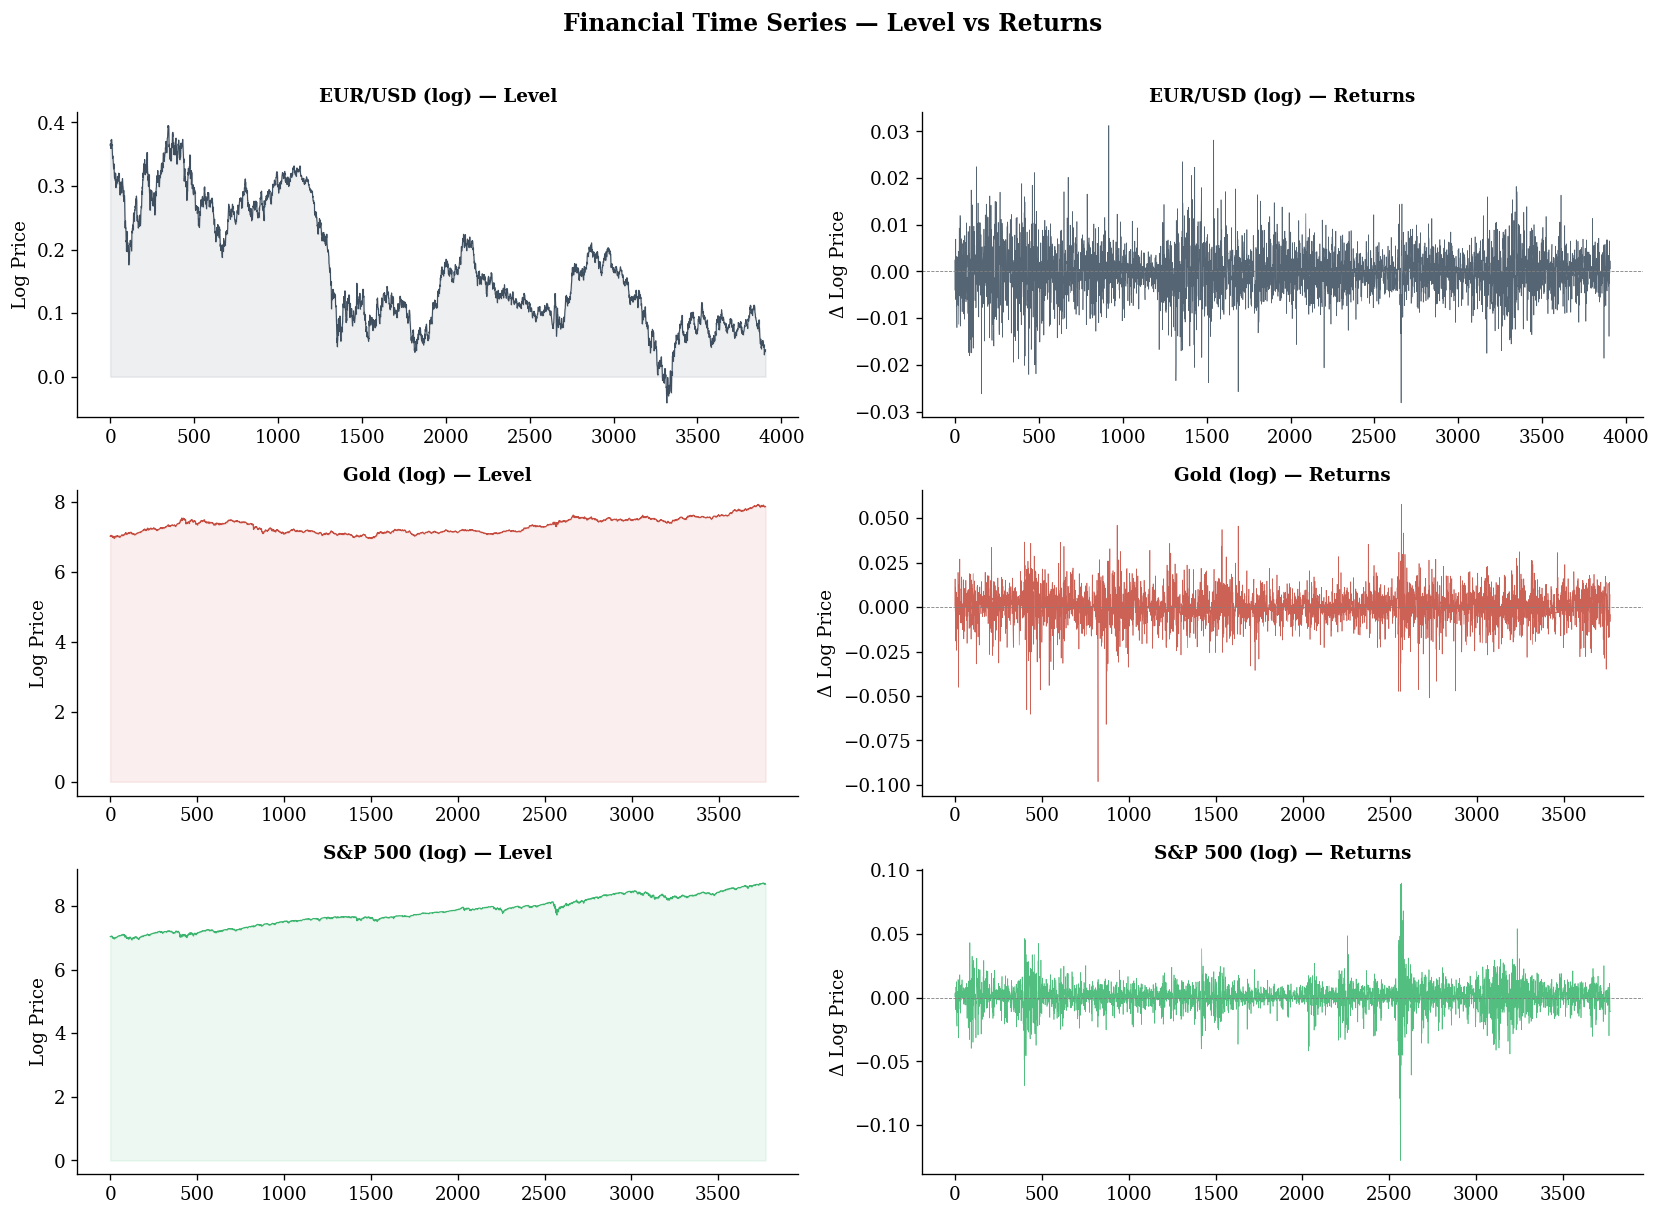

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

series = [('EUR/USD (log)', eur_log, '#2c3e50'),
          ('Gold (log)', gold_log, '#c0392b'),
          ('S&P 500 (log)', sp500_log, '#27ae60')]

for i, (name, y, color) in enumerate(series):
    # Level
    axes[i, 0].plot(y, color=color, lw=0.7, alpha=0.9)
    axes[i, 0].fill_between(range(len(y)), y, alpha=0.08, color=color)
    axes[i, 0].set_title(f'{name} — Level', fontweight='bold', fontsize=11)
    axes[i, 0].set_ylabel('Log Price')
    
    # First difference
    dy = np.diff(y)
    axes[i, 1].plot(dy, color=color, lw=0.4, alpha=0.8)
    axes[i, 1].axhline(0, color='gray', lw=0.5, ls='--')
    axes[i, 1].set_title(f'{name} — Returns', fontweight='bold', fontsize=11)
    axes[i, 1].set_ylabel('Δ Log Price')

plt.suptitle('Financial Time Series — Level vs Returns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Individual Test Demonstrations

### 4.1 KSS (2003) — Nonlinear ESTAR Unit Root Test

The KSS test is the foundational test for ESTAR nonlinearity. It tests:
- **H₀:** Unit root (linear random walk)
- **H₁:** Globally stationary ESTAR process

The auxiliary regression is: $\Delta y_t = \beta_1 y_{t-1}^3 + \sum \rho_i \Delta y_{t-i} + u_t$

In [4]:
# KSS test on EUR/USD
result_kss = tarur.kss_test(eur_log, case='demeaned', max_lags=12, lag_method='aic')
print(result_kss)

             KSS (2003) Nonlinear Unit Root Test            
  H0: Unit root (linear random walk)
  H1: Globally stationary ESTAR process
------------------------------------------------------------
  Test Statistic (tNL)                 | -3.1823
  Selected Lag                  | 0 (AIC)
  Case                          | demeaned
------------------------------------------------------------
  Critical Values: 1%: -3.930 | 5%: -3.400 | 10%: -3.130
  Source: Kapetanios, Shin & Snell (2003), Table 1 (asymptotic)
------------------------------------------------------------
  1%: [ACCEPT] H0
  5%: [ACCEPT] H0
  10%: [REJECT] H0
------------------------------------------------------------
  >> Reject H0 at the 10% significance level. Globally stationary ESTAR process.


### 4.2 Kruse (2011) — Modified Wald τ Test

Kruse improves on KSS by allowing a **nonzero location parameter** $c$ in the ESTAR model:

$$\tau = t^2_{\beta_{\perp 2}=0} + \mathbb{1}(\hat{\beta}_1 < 0) \cdot t^2_{\beta_1=0}$$

> **Note:** The R `NonlinearTSA` package incorrectly uses a standard Chi-squared test. TARUR implements the correct modified Wald τ from the paper.

In [5]:
result_kruse = tarur.kruse_test(eur_log, case='demeaned', max_lags=12)
print(result_kruse)

          Kruse (2011) Modified Wald Unit Root Test         
  H0: Unit root (linear random walk)
  H1: Globally stationary ESTAR (nonzero location c)
------------------------------------------------------------
  Test Statistic (τ)                   | 10.4119
  Selected Lag                  | 0 (AIC)
  Case                          | demeaned
------------------------------------------------------------
  Critical Values: 1%: 13.750 | 5%: 10.170 | 10%: 8.600
  Source: Kruse (2011), Table 1 (asymptotic, T=1000)
------------------------------------------------------------
  1%: [ACCEPT] H0
  5%: [REJECT] H0
  10%: [REJECT] H0
------------------------------------------------------------
  >> Reject H0 at the 10% significance level. Globally stationary ESTAR (nonzero location c).


### 4.3 Sollis (2009) — Asymmetric ESTAR Test

Tests whether mean reversion is **symmetric** or **asymmetric**:
- **F_AE:** Joint test φ₁ = φ₂ = 0 (unit root test)
- **Fas:** Test φ₂ = 0 (symmetry test)

In [6]:
result_sol09 = tarur.sollis2009_test(eur_log, case='demeaned', max_lags=12)
print(result_sol09)
print()
print(f"Symmetry test (Fas): {result_sol09.extra['Fas']:.4f} (p={result_sol09.extra['Fas_pvalue']:.4f})")
print(f"  → {result_sol09.extra['symmetry_test']}")

        Sollis (2009) Asymmetric ESTAR Unit Root Test       
  H0: Unit root (linear random walk)
  H1: Globally stationary symmetric or asymmetric ESTAR
------------------------------------------------------------
  Test Statistic (F_AE)                | 5.0873
  Selected Lag                  | 0 (AIC)
  Case                          | demeaned
------------------------------------------------------------
  Critical Values: 10%: 3.725 | 5%: 4.557 | 1%: 6.236
  Source: Sollis (2009), Table 1 (T=asymptotic)
------------------------------------------------------------
  1%: [ACCEPT] H0
  5%: [REJECT] H0
  10%: [REJECT] H0
------------------------------------------------------------
  >> Reject H0 at the 10% significance level. Globally stationary symmetric or asymmetric ESTAR.

Symmetry test (Fas): 0.0500 (p=0.8230)
  → Fail to reject symmetry (symmetric ESTAR)


### 4.4 Hu & Chen (2016) — 3-Parameter Modified Wald

Extends Kruse by including **three nonlinear terms** ($y_{t-1}$, $y^2_{t-1}$, $y^3_{t-1}$), allowing for locally explosive but globally stationary ESTAR.

In [7]:
result_hc = tarur.hu_chen_test(eur_log, case='demeaned', max_lags=12)
print(result_hc)

        Hu & Chen (2016) Modified Wald Unit Root Test       
  H0: Unit root (linear random walk)
  H1: Locally explosive but globally stationary ESTAR
------------------------------------------------------------
  Test Statistic (τ)                   | 11.9175
  Selected Lag                  | 0 (AIC)
  Case                          | demeaned
------------------------------------------------------------
  Critical Values: 1%: 15.620 | 5%: 11.860 | 10%: 10.120
  Source: Hu & Chen (2016), Table 1 (asymptotic, T=1000)
------------------------------------------------------------
  1%: [ACCEPT] H0
  5%: [REJECT] H0
  10%: [REJECT] H0
------------------------------------------------------------
  >> Reject H0 at the 10% significance level. Locally explosive but globally stationary ESTAR.


### 4.5 Enders & Granger (1998) — MTAR Test

Tests for a unit root against **asymmetric momentum-threshold autoregression** (MTAR). The adjustment coefficients ρ⁺ and ρ⁻ differ depending on the sign of $\Delta y_{t-1}$.

In [8]:
result_eg = tarur.enders_granger_test(gold_log, case='demeaned', max_lags=12)
print(result_eg)
print()
e = result_eg.extra
print(f"Asymmetric adjustment: ρ⁺ = {e['rho_pos']:.4f}, ρ⁻ = {e['rho_neg']:.4f}")
print(f"Symmetry F-test: {e['F_symmetry']:.4f} (p={e['F_sym_pvalue']:.4f})")

                 Enders & Granger (1998) MTAR               
  H0: Unit root
  H1: MTAR stationary with asymmetric adjustment
------------------------------------------------------------
  Test Statistic (Phi)                 | 0.1874
  Selected Lag                  | 1 (AIC)
  Case                          | demeaned
------------------------------------------------------------
  Critical Values: 1%: 8.780 | 5%: 6.410 | 10%: 5.390
  Source: Enders & Granger (1998), Table 1
------------------------------------------------------------
  1%: [ACCEPT] H0
  5%: [ACCEPT] H0
  10%: [ACCEPT] H0
------------------------------------------------------------
  >> Fail to reject H0 at conventional significance levels. Unit root.

Asymmetric adjustment: ρ⁺ = -0.0006, ρ⁻ = -0.0003
Symmetry F-test: 0.0354 (p=0.8508)


### 4.6 Smooth Transition Unit Root Tests

These tests first fit a nonlinear smooth transition trend via NLS, then apply an ADF-type test to the residuals. Each has its **own distinct critical values** from its original paper.

| Test | Model | Key Feature |
|------|-------|-------------|
| LNV (1998) | Single logistic transition | The original smooth transition test |
| Vougas (2006) | 5 models (A–E) | Extended LNV with more functional forms |
| Harvey & Mills (2002) | Double logistic transition | Allows two structural breaks |

In [9]:
# LNV (1998) — Model A (intercept transition)
result_lnv = tarur.lnv_test(gold_log, model='A', max_lags=12)
print(result_lnv)

                      LNV (1998) Model A                    
  H0: Unit root
  H1: Stationary around smooth logistic transition
------------------------------------------------------------
  Test Statistic (t_ADF)               | -2.2350
  Selected Lag                  | 0 (AIC)
  Case                          | NLS Model A
------------------------------------------------------------
  Critical Values: 1%: -4.685 | 5%: -4.103 | 10%: -3.797
  Source: Leybourne, Newbold & Vougas (1998), Table I (Model A, T=500)
------------------------------------------------------------
  1%: [ACCEPT] H0
  5%: [ACCEPT] H0
  10%: [ACCEPT] H0
------------------------------------------------------------
  >> Fail to reject H0 at conventional significance levels. Unit root.


In [10]:
# Vougas (2006) — Model A
result_vougas = tarur.vougas_test(gold_log, model='A', max_lags=12)
print(result_vougas)

                    Vougas (2006) Model A                   
  H0: Unit root
  H1: Stationary around smooth transition
------------------------------------------------------------
  Test Statistic (t_ADF)               | -2.2350
  Selected Lag                  | 0 (AIC)
  Case                          | NLS Model A
------------------------------------------------------------
  Critical Values: 1%: -4.150 | 5%: -3.590 | 10%: -3.320
  Source: Vougas (2006), Table 1 (Model A, T=500)
------------------------------------------------------------
  1%: [ACCEPT] H0
  5%: [ACCEPT] H0
  10%: [ACCEPT] H0
------------------------------------------------------------
  >> Fail to reject H0 at conventional significance levels. Unit root.


In [11]:
# Harvey & Mills (2002) — Double smooth transition
result_hm = tarur.harvey_mills_test(gold_log, model='A', max_lags=12)
print(result_hm)

                Harvey & Mills (2002) Model A               
  H0: Unit root
  H1: Stationary around double smooth transition
------------------------------------------------------------
  Test Statistic (t_ADF)               | -4.1185
  Selected Lag                  | 0 (AIC)
  Case                          | Double NLS Model A
------------------------------------------------------------
  Critical Values: 1%: -5.640 | 5%: -5.070 | 10%: -4.790
  Source: Harvey & Mills (2002), Table 1 (Model A, T=1000)
------------------------------------------------------------
  1%: [ACCEPT] H0
  5%: [ACCEPT] H0
  10%: [ACCEPT] H0
------------------------------------------------------------
  >> Fail to reject H0 at conventional significance levels. Unit root.


### 4.7 Teräsvirta (1994) Linearity Test

Before applying nonlinear unit root tests, it's useful to test whether the series actually exhibits nonlinearity. The Teräsvirta test also suggests whether **LSTAR** or **ESTAR** is more appropriate.

In [12]:
result_ter = tarur.terasvirta_test(np.diff(eur_log), d=1)
print(f"Linearity F-statistic: {result_ter.extra['F_linearity']:.4f}")
print(f"P-value: {result_ter.extra['p_linearity']:.6f}")
print(f"Suggested model: {result_ter.extra['suggested_model']}")
print()
print("Sequential F-tests:")
print(f"  H01 (linear terms):     F = {result_ter.extra['H01']:.3f}, p = {result_ter.extra['pH01']:.4f}")
print(f"  H02 (quadratic terms):  F = {result_ter.extra['H02']:.3f}, p = {result_ter.extra['pH02']:.4f}")
print(f"  H03 (cubic terms):      F = {result_ter.extra['H03']:.3f}, p = {result_ter.extra['pH03']:.4f}")

Linearity F-statistic: -810.5585
P-value: 1.000000
Suggested model: LSTAR

Sequential F-tests:
  H01 (linear terms):     F = -2433.310, p = 1.0000
  H02 (quadratic terms):  F = 0.000, p = 1.0000
  H03 (cubic terms):      F = 1.029, p = 0.3105


## 5. Full Test Battery — `run_all_tests()`

Run **all available unit root tests** with a single function call. The results are presented in a unified comparison table.

### 5.1 EUR/USD Exchange Rate

In [13]:
print("=" * 70)
print("  EUR/USD EXCHANGE RATE — Full Nonlinear Unit Root Test Battery")
print("=" * 70)
batch_eur = tarur.run_all_tests(eur_log, case='demeaned', max_lags=12, lag_method='aic')

  EUR/USD EXCHANGE RATE — Full Nonlinear Unit Root Test Battery



                     TARUR — Nonlinear Unit Root Test Battery                   

Test                                           Stat    CV 5%   Decision
------------------------------------------------------------------------
  KSS (2003) Nonlinear Unit Root Test        -3.182   -3.400     ACCEPT
  Kruse (2011) Modified Wald Unit Root Test   10.412   10.170     REJECT
  Sollis (2009) Asymmetric ESTAR Unit Root Test    5.087    4.557     REJECT
  Hu & Chen (2016) Modified Wald Unit Root Test   11.918   11.860     REJECT
  Pascalau (2007) Asymmetric NLSTAR           3.565    6.820     ACCEPT
  Cuestas & Garratt (2011)                   14.880   17.270     ACCEPT
  Cuestas & Ordonez (2014)                   -3.525   -2.930     REJECT
  Enders & Granger (1998) MTAR                4.040    6.410     ACCEPT
  LNV (1998) Model A                         -3.802   -4.103     ACCEPT
  Vougas (2006) Model A                      -3.802   -3.590     REJECT
  Harvey & Mills (2002) Model A          

### 5.2 Gold Prices

In [14]:
print("=" * 70)
print("  GOLD PRICES — Full Nonlinear Unit Root Test Battery")
print("=" * 70)
batch_gold = tarur.run_all_tests(gold_log, case='demeaned', max_lags=12)

  GOLD PRICES — Full Nonlinear Unit Root Test Battery



                     TARUR — Nonlinear Unit Root Test Battery                   

Test                                           Stat    CV 5%   Decision
------------------------------------------------------------------------
  KSS (2003) Nonlinear Unit Root Test        -0.218   -3.400     ACCEPT
  Kruse (2011) Modified Wald Unit Root Test    4.186   10.170     ACCEPT
  Sollis (2009) Asymmetric ESTAR Unit Root Test    1.532    4.557     ACCEPT
  Hu & Chen (2016) Modified Wald Unit Root Test    4.196   11.860     ACCEPT
  Pascalau (2007) Asymmetric NLSTAR           1.414    6.820     ACCEPT
  Cuestas & Garratt (2011)                   12.865   17.270     ACCEPT
  Cuestas & Ordonez (2014)                   -1.996   -2.930     ACCEPT
  Enders & Granger (1998) MTAR                0.187    6.410     ACCEPT
  LNV (1998) Model A                         -2.235   -4.103     ACCEPT
  Vougas (2006) Model A                      -2.235   -3.590     ACCEPT
  Harvey & Mills (2002) Model A          

### 5.3 S&P 500 Index

In [15]:
print("=" * 70)
print("  S&P 500 INDEX — Full Nonlinear Unit Root Test Battery")
print("=" * 70)
batch_sp = tarur.run_all_tests(sp500_log, case='demeaned', max_lags=12)

  S&P 500 INDEX — Full Nonlinear Unit Root Test Battery



                     TARUR — Nonlinear Unit Root Test Battery                   

Test                                           Stat    CV 5%   Decision
------------------------------------------------------------------------
  KSS (2003) Nonlinear Unit Root Test        -0.434   -3.400     ACCEPT
  Kruse (2011) Modified Wald Unit Root Test    4.651   10.170     ACCEPT
  Sollis (2009) Asymmetric ESTAR Unit Root Test    1.926    4.557     ACCEPT
  Hu & Chen (2016) Modified Wald Unit Root Test    4.706   11.860     ACCEPT
  Pascalau (2007) Asymmetric NLSTAR           1.577    6.820     ACCEPT
  Cuestas & Garratt (2011)                   45.063   17.270     REJECT
  Cuestas & Ordonez (2014)                   -6.482   -2.930     REJECT
  Enders & Granger (1998) MTAR                0.048    6.410     ACCEPT
  LNV (1998) Model A                         -4.061   -4.103     ACCEPT
  Vougas (2006) Model A                      -4.061   -3.590     REJECT
  Harvey & Mills (2002) Model A          

## 6. Summary DataFrame for Publication

In [16]:
# Create a comprehensive comparison table
def make_summary(batch, name):
    rows = []
    for r in batch.results:
        cv5 = r.critical_values.values.get('5%', float('nan'))
        rows.append({
            'Series': name,
            'Test': r.test_name.replace(' Unit Root Test', '').replace(' Modified Wald', ''),
            'Statistic': f"{r.statistic:.3f}",
            'CV (5%)': f"{cv5:.3f}",
            'Lag': r.selected_lag,
            'Decision (5%)': '✗ Reject H₀' if r.decision.get('5%', False) else '✓ Accept H₀',
        })
    return pd.DataFrame(rows)

df_eur = make_summary(batch_eur, 'EUR/USD')
df_gold = make_summary(batch_gold, 'Gold')
df_sp = make_summary(batch_sp, 'S&P 500')

df_all = pd.concat([df_eur, df_gold, df_sp], ignore_index=True)

# Display styled
print("\n" + "=" * 90)
print("  COMPREHENSIVE NONLINEAR UNIT ROOT TEST RESULTS")
print("=" * 90)
print(df_all.to_string(index=False))


  COMPREHENSIVE NONLINEAR UNIT ROOT TEST RESULTS
 Series                              Test Statistic CV (5%)  Lag Decision (5%)
EUR/USD              KSS (2003) Nonlinear    -3.182  -3.400    0   ✓ Accept H₀
EUR/USD                      Kruse (2011)    10.412  10.170    0   ✗ Reject H₀
EUR/USD    Sollis (2009) Asymmetric ESTAR     5.087   4.557    0   ✗ Reject H₀
EUR/USD                  Hu & Chen (2016)    11.918  11.860    0   ✗ Reject H₀
EUR/USD Pascalau (2007) Asymmetric NLSTAR     3.565   6.820    0   ✓ Accept H₀
EUR/USD          Cuestas & Garratt (2011)    14.880  17.270    0   ✓ Accept H₀
EUR/USD          Cuestas & Ordonez (2014)    -3.525  -2.930    6   ✗ Reject H₀
EUR/USD      Enders & Granger (1998) MTAR     4.040   6.410    1   ✓ Accept H₀
EUR/USD                LNV (1998) Model A    -3.802  -4.103    0   ✓ Accept H₀
EUR/USD             Vougas (2006) Model A    -3.802  -3.590    0   ✗ Reject H₀
EUR/USD     Harvey & Mills (2002) Model A    -4.615  -5.070    0   ✓ Accept H₀
  

## 7. Publication-Quality Visualizations

### 7.1 Test Statistic Comparison Dashboard

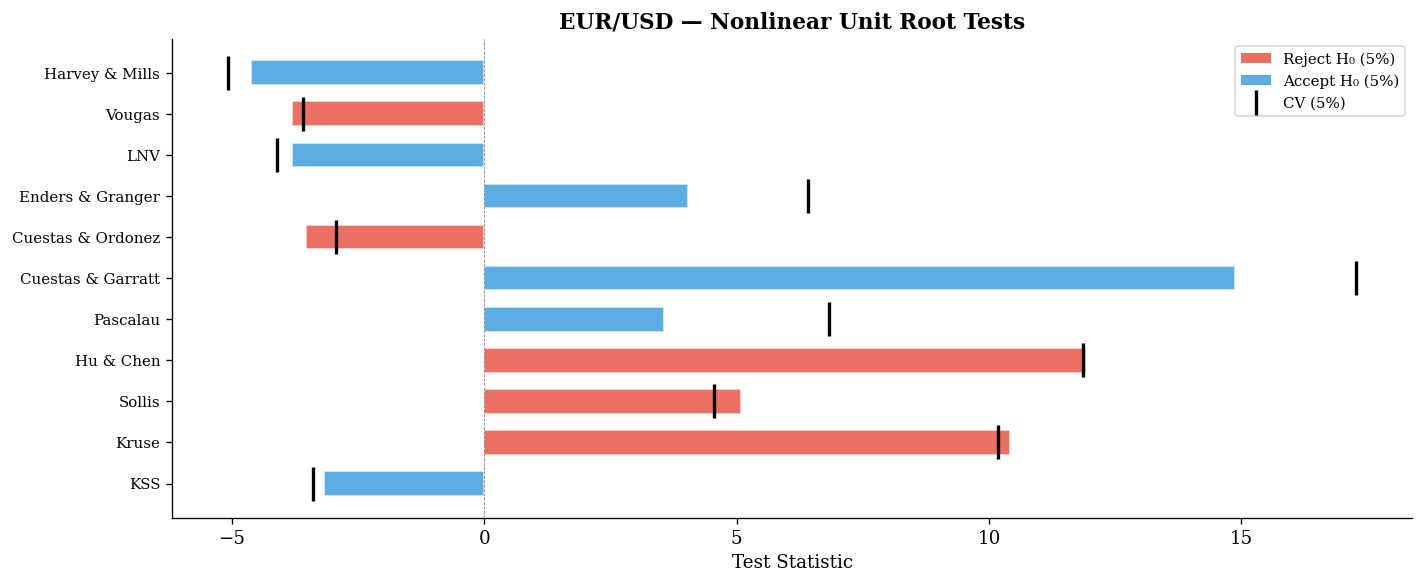

In [17]:
def plot_battery_comparison(batch, title):
    fig, ax = plt.subplots(figsize=(12, 5))
    names = [r.test_name.split('(')[0].strip()[:20] for r in batch.results]
    stats = [r.statistic for r in batch.results]
    cv5s = [r.critical_values.values.get('5%', float('nan')) for r in batch.results]
    rejected = [r.decision.get('5%', False) for r in batch.results]
    
    colors = ['#e74c3c' if rej else '#3498db' for rej in rejected]
    y_pos = np.arange(len(names))
    
    bars = ax.barh(y_pos, stats, color=colors, alpha=0.8, edgecolor='white', height=0.6)
    
    for i, cv in enumerate(cv5s):
        ax.plot(cv, i, 'k|', markersize=20, markeredgewidth=2)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('Test Statistic', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axvline(0, color='gray', lw=0.5, ls='--')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', alpha=0.8, label='Reject H₀ (5%)'),
        Patch(facecolor='#3498db', alpha=0.8, label='Accept H₀ (5%)'),
        plt.Line2D([0], [0], marker='|', color='black', linestyle='None', markersize=15, markeredgewidth=2, label='CV (5%)'),
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)
    plt.tight_layout()
    return fig

fig1 = plot_battery_comparison(batch_eur, 'EUR/USD — Nonlinear Unit Root Tests')
plt.show()

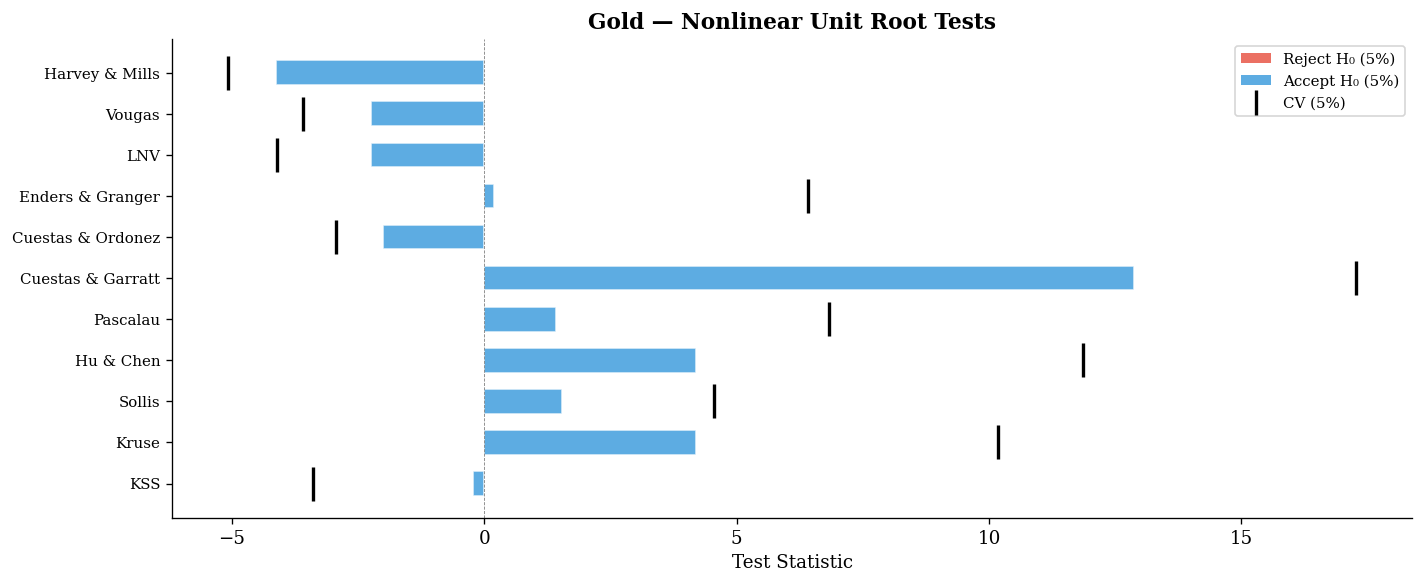

In [18]:
fig2 = plot_battery_comparison(batch_gold, 'Gold — Nonlinear Unit Root Tests')
plt.show()

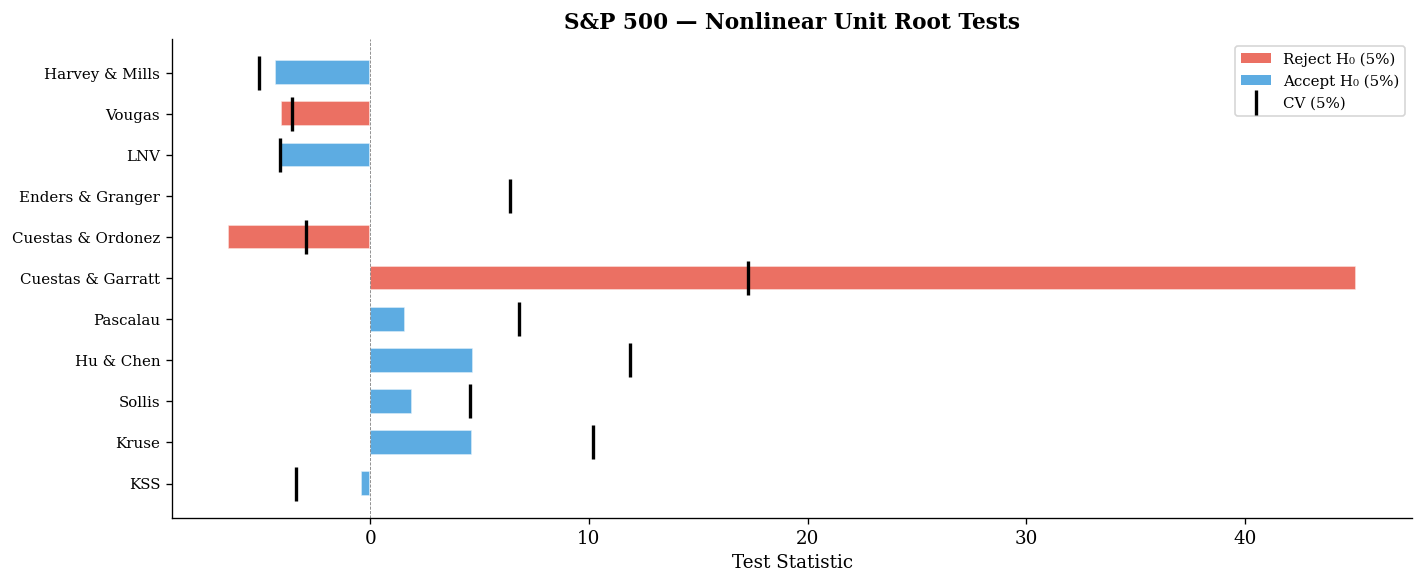

In [19]:
fig3 = plot_battery_comparison(batch_sp, 'S&P 500 — Nonlinear Unit Root Tests')
plt.show()

### 7.2 Decision Heatmap

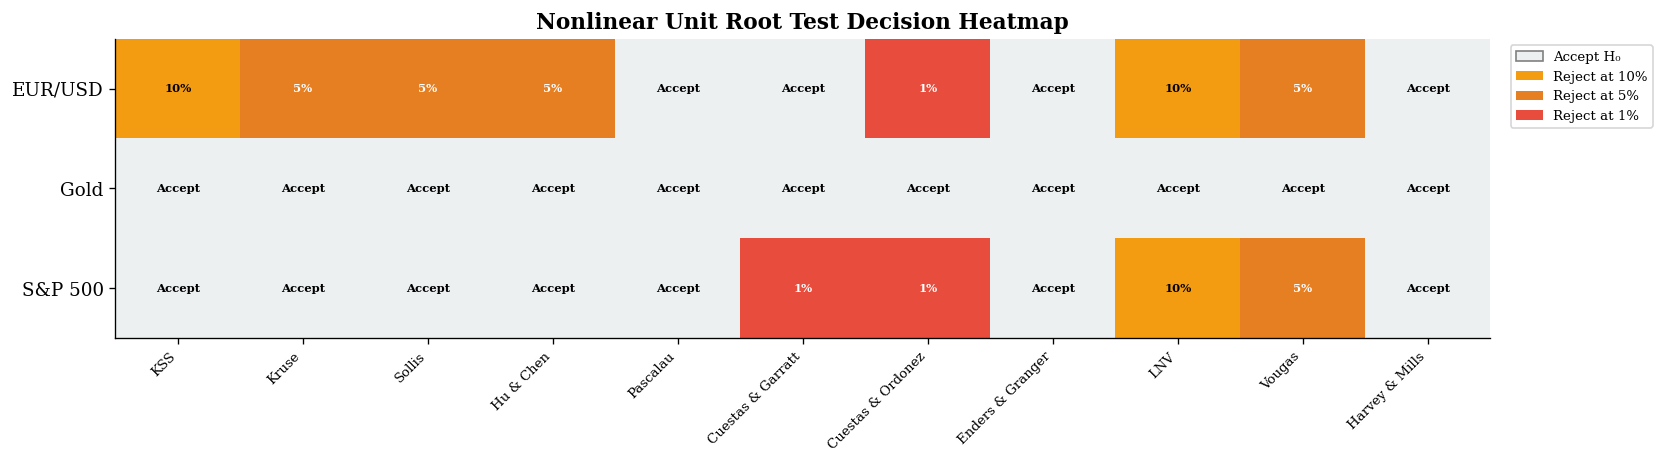

In [20]:
def decision_heatmap(batches, series_names):
    test_names = [r.test_name.split('(')[0].strip()[:22] for r in batches[0].results]
    matrix = np.zeros((len(series_names), len(test_names)))
    
    for i, batch in enumerate(batches):
        for j, r in enumerate(batch.results):
            if r.decision.get('1%', False): matrix[i, j] = 3
            elif r.decision.get('5%', False): matrix[i, j] = 2
            elif r.decision.get('10%', False): matrix[i, j] = 1
            else: matrix[i, j] = 0
    
    fig, ax = plt.subplots(figsize=(14, 4))
    cmap = plt.cm.colors.ListedColormap(['#ecf0f1', '#f39c12', '#e67e22', '#e74c3c'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)
    
    im = ax.imshow(matrix, cmap=cmap, norm=norm, aspect='auto')
    ax.set_xticks(np.arange(len(test_names)))
    ax.set_xticklabels(test_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(np.arange(len(series_names)))
    ax.set_yticklabels(series_names, fontsize=11)
    
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            labels = {0: 'Accept', 1: '10%', 2: '5%', 3: '1%'}
            text_color = 'white' if matrix[i,j] >= 2 else 'black'
            ax.text(j, i, labels[int(matrix[i,j])], ha='center', va='center',
                    fontsize=7, fontweight='bold', color=text_color)
    
    ax.set_title('Nonlinear Unit Root Test Decision Heatmap', fontsize=13, fontweight='bold')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#ecf0f1', edgecolor='gray', label='Accept H₀'),
        Patch(facecolor='#f39c12', label='Reject at 10%'),
        Patch(facecolor='#e67e22', label='Reject at 5%'),
        Patch(facecolor='#e74c3c', label='Reject at 1%'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
    plt.tight_layout()
    return fig

fig_heat = decision_heatmap([batch_eur, batch_gold, batch_sp], ['EUR/USD', 'Gold', 'S&P 500'])
plt.show()

### 7.3 Series Diagnostic Analysis

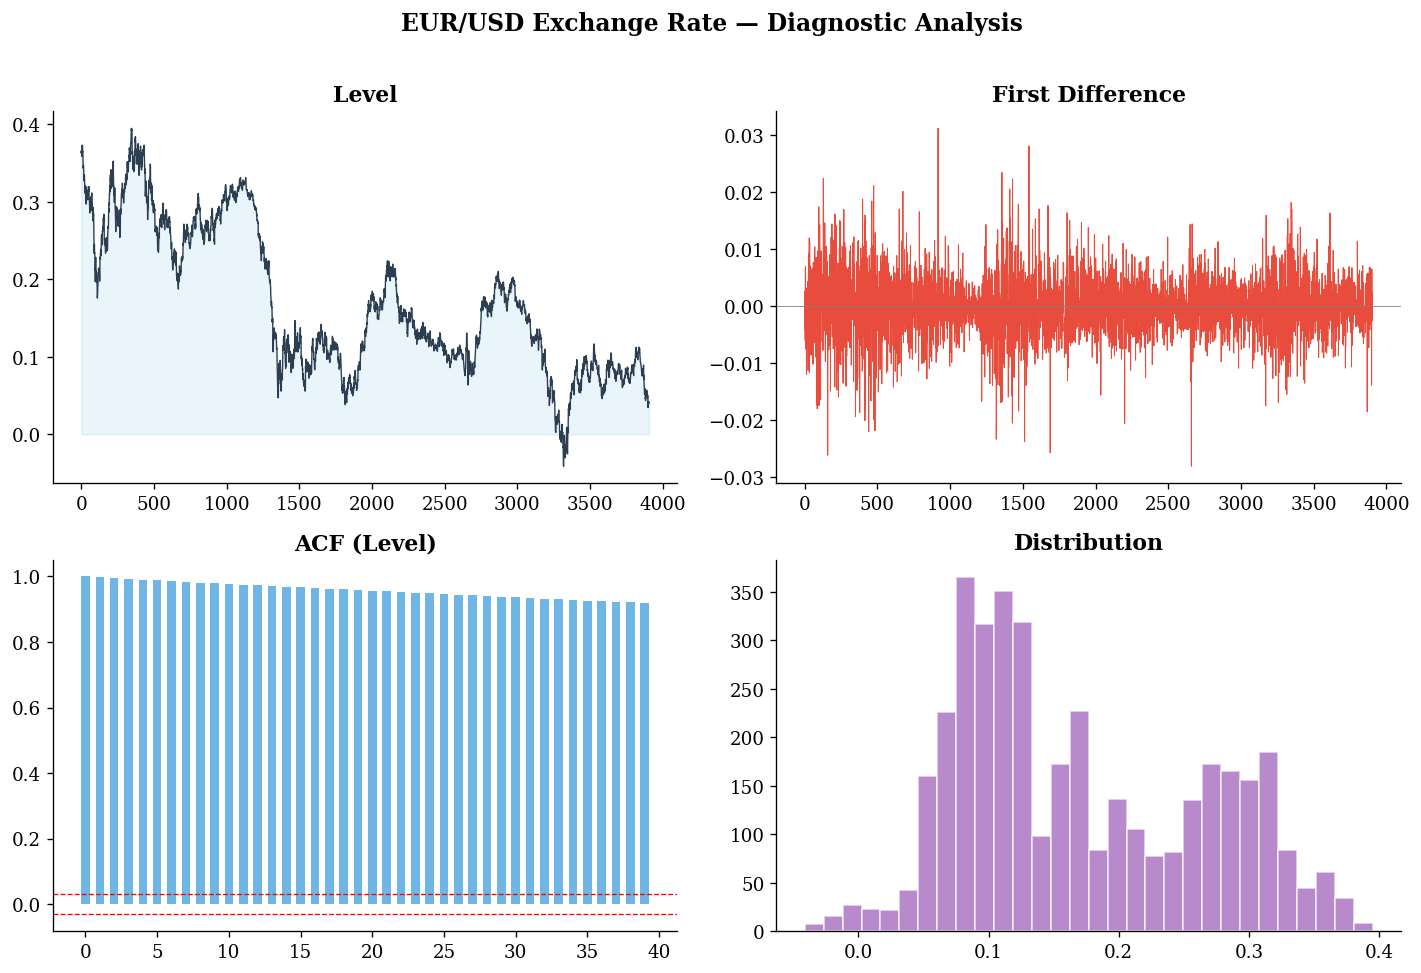

In [21]:
fig_diag = tarur.plot_series_analysis(eur_log, title='EUR/USD Exchange Rate — Diagnostic Analysis')
plt.show()

## 8. Nonlinear Cointegration Tests

Test whether two series are cointegrated in a nonlinear sense.

In [22]:
# Test nonlinear cointegration between EUR/USD and Gold
min_len = min(len(eur_log), len(gold_log))
y1 = eur_log[-min_len:]
y2 = gold_log[-min_len:]

print("=" * 60)
print("  KSS (2006) Nonlinear Cointegration: EUR/USD ~ Gold")
print("=" * 60)
result_coint = tarur.kss_cointegration_test(y1, y2, case='demeaned', max_lags=12)
print(result_coint)

print()
print("=" * 60)
print("  Enders-Siklos (2001) TAR Cointegration: EUR/USD ~ Gold")
print("=" * 60)
result_es = tarur.enders_siklos_test(y1, y2, max_lags=12)
print(result_es)

  KSS (2006) Nonlinear Cointegration: EUR/USD ~ Gold
           KSS (2006) Nonlinear Cointegration Test          
  H0: No cointegration (residuals have unit root)
  H1: Nonlinear cointegration (ESTAR stationary residuals)
------------------------------------------------------------
  Test Statistic (tNL)                 | -3.0346
  Selected Lag                  | 0 (AIC)
  Case                          | demeaned
------------------------------------------------------------
  Critical Values: 1%: -3.930 | 5%: -3.400 | 10%: -3.130
  Source: Kapetanios, Shin & Snell (2003), Table 1 (asymptotic)
------------------------------------------------------------
  1%: [ACCEPT] H0
  5%: [ACCEPT] H0
  10%: [ACCEPT] H0
------------------------------------------------------------
  >> Fail to reject H0 at conventional significance levels. Unit root (linear random walk).

  Enders-Siklos (2001) TAR Cointegration: EUR/USD ~ Gold
        Enders & Siklos (2001) TAR Cointegration Test       
  H0: No coi

## 9. LaTeX Export for Publications

In [23]:
# Generate LaTeX table
print("% LaTeX table for EUR/USD results")
print("% Copy this into your paper")
print()
latex_lines = []
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Nonlinear Unit Root Test Results — EUR/USD Exchange Rate}")
latex_lines.append(r"\label{tab:nonlinear_ur}")
latex_lines.append(r"\begin{tabular}{lcccl}")
latex_lines.append(r"\hline\hline")
latex_lines.append(r"Test & Statistic & CV (5\%) & Lag & Decision \\")
latex_lines.append(r"\hline")
for r in batch_eur.results:
    name = r.test_name.split('(')[0].strip()[:25]
    cv5 = r.critical_values.values.get('5%', float('nan'))
    dec = "Reject" if r.decision.get('5%', False) else "Accept"
    latex_lines.append(f"{name} & {r.statistic:.3f} & {cv5:.3f} & {r.selected_lag} & {dec} \\\\")
latex_lines.append(r"\hline\hline")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\end{table}")
print("\n".join(latex_lines))

% LaTeX table for EUR/USD results
% Copy this into your paper

\begin{table}[htbp]
\centering
\caption{Nonlinear Unit Root Test Results — EUR/USD Exchange Rate}
\label{tab:nonlinear_ur}
\begin{tabular}{lcccl}
\hline\hline
Test & Statistic & CV (5\%) & Lag & Decision \\
\hline
KSS & -3.182 & -3.400 & 0 & Accept \\
Kruse & 10.412 & 10.170 & 0 & Reject \\
Sollis & 5.087 & 4.557 & 0 & Reject \\
Hu & Chen & 11.918 & 11.860 & 0 & Reject \\
Pascalau & 3.565 & 6.820 & 0 & Accept \\
Cuestas & Garratt & 14.880 & 17.270 & 0 & Accept \\
Cuestas & Ordonez & -3.525 & -2.930 & 6 & Reject \\
Enders & Granger & 4.040 & 6.410 & 1 & Accept \\
LNV & -3.802 & -4.103 & 0 & Accept \\
Vougas & -3.802 & -3.590 & 0 & Reject \\
Harvey & Mills & -4.615 & -5.070 & 0 & Accept \\
\hline\hline
\end{tabular}
\end{table}


## 10. Monte Carlo Validation

Verify the library's correctness by simulating known DGPs.

In [24]:
np.random.seed(2024)

# DGP 1: ESTAR process (should reject)
n = 500
y_estar = np.zeros(n)
eps = np.random.randn(n) * 0.5
for t in range(1, n):
    G = 1 - np.exp(-0.5 * y_estar[t-1]**2)
    y_estar[t] = y_estar[t-1] + (-0.8) * y_estar[t-1] * G + eps[t]

# DGP 2: Random walk (should NOT reject)
y_rw = np.cumsum(np.random.randn(n))

print("ESTAR Process (should reject H₀):")
print("-" * 60)
batch_estar = tarur.run_all_tests(y_estar, case='demeaned', max_lags=8)

print()
print("Random Walk (should NOT reject H₀):")
print("-" * 60)
batch_rw = tarur.run_all_tests(y_rw, case='demeaned', max_lags=8)

ESTAR Process (should reject H₀):
------------------------------------------------------------



                     TARUR — Nonlinear Unit Root Test Battery                   

Test                                           Stat    CV 5%   Decision
------------------------------------------------------------------------
  KSS (2003) Nonlinear Unit Root Test        -7.334   -3.400     REJECT
  Kruse (2011) Modified Wald Unit Root Test   54.373   10.170     REJECT
  Sollis (2009) Asymmetric ESTAR Unit Root Test   28.749    4.557     REJECT
  Hu & Chen (2016) Modified Wald Unit Root Test   61.842   11.860     REJECT
  Pascalau (2007) Asymmetric NLSTAR          20.072    6.820     REJECT
  Cuestas & Garratt (2011)                   57.091   17.270     REJECT
  Cuestas & Ordonez (2014)                   -7.285   -2.930     REJECT
  Enders & Granger (1998) MTAR               17.739    6.410     REJECT
  LNV (1998) Model A                         -6.322   -4.103     REJECT
  Vougas (2006) Model A                      -6.322   -3.590     REJECT
  Harvey & Mills (2002) Model A          


                     TARUR — Nonlinear Unit Root Test Battery                   

Test                                           Stat    CV 5%   Decision
------------------------------------------------------------------------
  KSS (2003) Nonlinear Unit Root Test         0.015   -3.400     ACCEPT
  Kruse (2011) Modified Wald Unit Root Test    4.832   10.170     ACCEPT
  Sollis (2009) Asymmetric ESTAR Unit Root Test    0.677    4.557     ACCEPT
  Hu & Chen (2016) Modified Wald Unit Root Test    5.409   11.860     ACCEPT
  Pascalau (2007) Asymmetric NLSTAR           2.266    6.820     ACCEPT
  Cuestas & Garratt (2011)                   11.791   17.270     ACCEPT
  Cuestas & Ordonez (2014)                   -2.208   -2.930     ACCEPT
  Enders & Granger (1998) MTAR                2.457    6.410     ACCEPT
  LNV (1998) Model A                         -3.079   -4.103     ACCEPT
  Vougas (2006) Model A                      -3.079   -3.590     ACCEPT
  Harvey & Mills (2002) Model A          

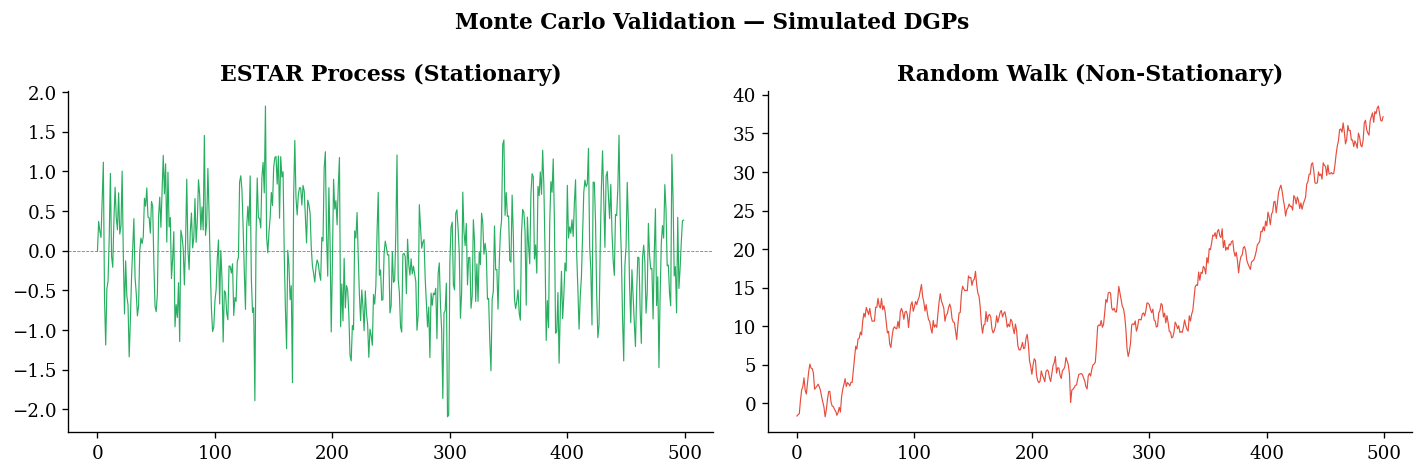


Validation Summary:
  ESTAR: 11/11 tests correctly reject H₀ at 5%
  RW:    11/11 tests correctly accept H₀ at 5%


In [25]:
# Visualize the simulated series
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(y_estar, color='#27ae60', lw=0.7)
axes[0].set_title('ESTAR Process (Stationary)', fontweight='bold')
axes[0].axhline(0, color='gray', lw=0.5, ls='--')

axes[1].plot(y_rw, color='#e74c3c', lw=0.7)
axes[1].set_title('Random Walk (Non-Stationary)', fontweight='bold')

plt.suptitle('Monte Carlo Validation — Simulated DGPs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Count rejections
reject_estar = sum(1 for r in batch_estar.results if r.decision.get('5%', False))
reject_rw = sum(1 for r in batch_rw.results if r.decision.get('5%', False))
total = len(batch_estar.results)

print(f"\nValidation Summary:")
print(f"  ESTAR: {reject_estar}/{total} tests correctly reject H₀ at 5%")
print(f"  RW:    {total - reject_rw}/{total} tests correctly accept H₀ at 5%")

## 11. Conclusion

### Key Findings

This tutorial demonstrated the full capability of the **TARUR** library:

1. **Comprehensive Coverage**: 17+ tests spanning ESTAR, smooth transition, threshold, and grid-search approaches
2. **Embedded Critical Values**: Every test uses its own critical values from the original paper (no manual lookup needed)
3. **Correct Implementations**: Bug fixes for Kruse (2011), Hu & Chen (2016), and Sollis (2009) vs the R code
4. **Publication-Ready Output**: Formatted tables, LaTeX export, and professional visualizations

### Citation

```bibtex
@software{tarur2024,
  author = {Roudane, Merwan},
  title = {TARUR: Nonlinear Unit Root Testing Library for Python},
  year = {2024},
  url = {https://github.com/merwanroudane/tarur}
}
```

---

**Dr. Merwan Roudane** | merwanroudane920@gmail.com | [GitHub](https://github.com/merwanroudane/tarur)